In [41]:
import sys 
import os

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from Matrix_methods.utils import get_frequency_domain
from Matrix_methods.Simulate import simulate_parallel, simulate_reference
from Matrix_methods.BayesianExtractor import BayesianLayeredExtractor
from Matrix_methods.AdamExtractor import LayeredExtractor



print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.0+cpu
CUDA available: False


In [42]:
# TODO:
# [a] run the 5_layer simulation, using the experimental reference pulse this time
# [b] run simulation using material parameters for HRZ_Si and Quartz samples 


In [43]:
def compare_material_stacks(calculated, real):
    """
    Compare two material parameter stacks with separate real/imag errors for n.
    
    Args:
        calculated (list of tuples): [(n_complex, thickness_m), ...]
        real (list of tuples): [(n_complex, thickness_m), ...]
    
    Returns:
        list of dicts with abs and % errors for n_real, n_imag, and thickness.
    """
    results = []
    for i, ((n_calc, d_calc), (n_true, d_true)) in enumerate(zip(calculated, real), start=1):
        
        # Refractive index real part errors
        n_real_abs_err = abs(n_calc.real - n_true.real)
        n_real_pct_err = (n_real_abs_err / abs(n_true.real)) * 100 if n_true.real != 0 else float('inf')
        
        # Refractive index imaginary part errors
        n_imag_abs_err = abs(n_calc.imag - n_true.imag)
        n_imag_pct_err = (n_imag_abs_err / abs(n_true.imag)) * 100 if n_true.imag != 0 else float('inf')

        # Thickness errors
        d_abs_err = abs(d_calc - d_true)
        d_pct_err = (d_abs_err / abs(d_true)) * 100 if d_true != 0 else float('inf')

        results.append({
            "layer": i,
            "n_real_abs_err": n_real_abs_err,
            "n_real_pct_err": n_real_pct_err,
            "n_imag_abs_err": n_imag_abs_err,
            "n_imag_pct_err": n_imag_pct_err,
            "d_abs_err": d_abs_err,
            "d_pct_err": d_pct_err
        })
    
    return results

In [44]:
# In this part, I will insert a reference pulse that is based on our experimental data.

# INSERT REFERENCE DATA 
reference_pulse = np.loadtxt(r"C:\miniconda_projects\repository\TerahertzProject\TheoTHzTDS\THz-TDS\Transfer Matrix Method\data_11_02_2026\Reference_15min_nitrogen (1).txt",dtype=float)

t1= reference_pulse[:,0] + 740  # ADJUISTING THE AXIS
amp1 = reference_pulse[:,1]




| Refractive Index | Absorption Coeff | Thickness [µm] |
|------------------|------------------|----------------|
|            1.962 |        -0.007100 |      1.000e-03 |
|            3.410 |        -0.005400 |      4.000e-04 |
(Negative absorption coeff means loss in the material.)

Total Thickness: 1400.0 µm


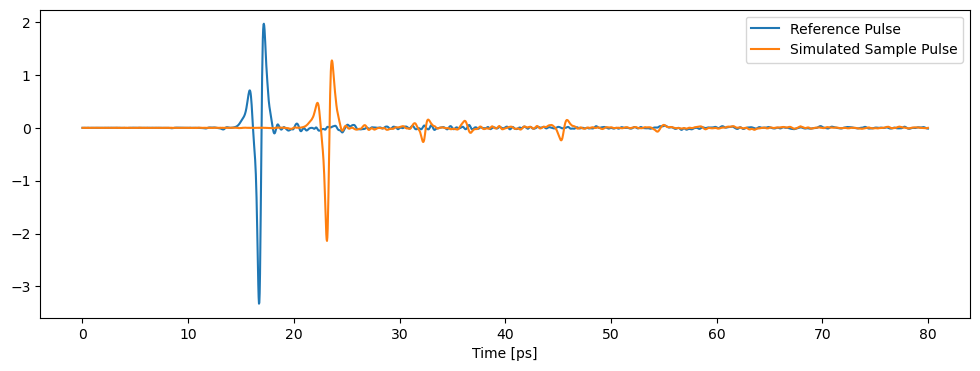

3.30033000000185e-14


In [45]:
# Simulation parameters
deltat = t1[1] - t1[0] 
deltat = deltat * 1e-12 # Time step, corect units, since we need to be using seconds instead of picoseconds
L = len(reference_pulse)  # Number of time points

reference_pulse = torch.tensor(amp1, dtype=torch.float32) # I'm converting the reference pulse to a tensor



n_values = [1.962,3.41]
k_values = [-0.0071, -0.0054]
d_values = [1e-3, 400e-6]  # Thicknesses meters (1 mm, 400 µm)

# Experimental material parameters (ground truth)
material_params_exp = [[(n_values[i] + 1j * k_values[i]), d_values[i]] for i in range(len(n_values))]


# Simulate the experimental data
t_axis = np.arange(0, L * deltat, deltat)
T_exp, experimental_pulse = simulate_parallel(reference_pulse, material_params_exp, deltat, noise_level=0.001)
experimental_pulse = experimental_pulse[:L]


print("| Refractive Index | Absorption Coeff | Thickness [µm] |")
print("|------------------|------------------|----------------|")

for item in material_params_exp:
    n_real = np.real(item[0])
    n_imag = np.imag(item[0])
    thickness = item[1]
    print(f"| {n_real:16.3f} | {n_imag:16.6f} | {thickness:14.3e} |")

print('(Negative absorption coeff means loss in the material.)')

print(f'\nTotal Thickness: {sum(d_values) * 1e6} µm')

plt.figure(figsize=(12,4))
#plt.title(f'Simulated Time Domain of THz Pulse Passing Through a {len(n_values)} Layered Sample')
plt.plot(t_axis*1e12, reference_pulse, label='Reference Pulse')
plt.plot(t_axis*1e12, experimental_pulse.detach().cpu().numpy(), label='Simulated Sample Pulse')
#plt.scatter(t_axis*1e12, experimental_pulse.detach().cpu().numpy(), s=2, color= 'orange', label='Simulated Sample Pulse')
plt.xlabel('Time [ps]')
plt.legend()
plt.show()

print(deltat)

N: 2425 frequency points


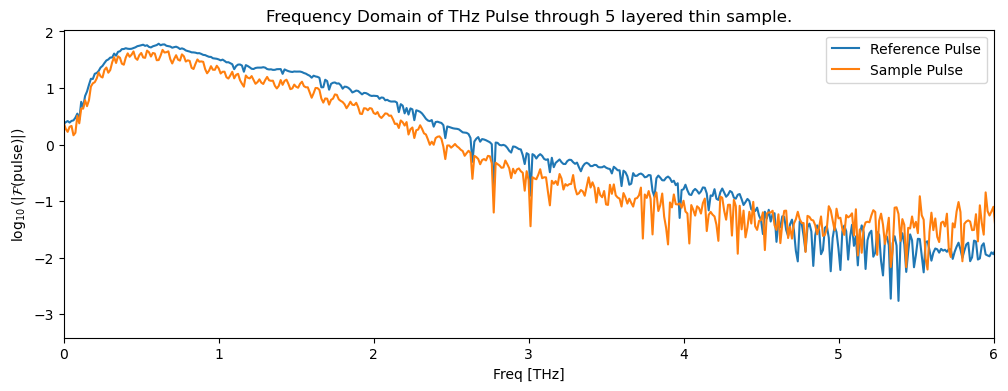

In [46]:
# Convert to frequency
freqs_ref, spectrum_ref = get_frequency_domain(reference_pulse, deltat=deltat)
freqs_sample, spectrum_sample = get_frequency_domain(experimental_pulse, deltat=deltat)

N = len(freqs_ref)
print(f'N: {N} frequency points')

plt.figure(figsize=(12,4))
plt.title('Frequency Domain of THz Pulse through 5 layered thin sample.')
plt.plot(freqs_ref[:N//2]*1e-12, np.real(np.log10(spectrum_ref[:N//2].detach().cpu().numpy())), label='Reference Pulse')
plt.plot(freqs_sample[:N//2]*1e-12, np.real(np.log10(spectrum_sample[:N//2].detach().cpu().numpy())), label='Sample Pulse')
plt.ylabel(r'$\log_{10}(|\mathcal{F}(\mathrm{pulse})|)$')
plt.xlabel('Freq [THz]')
plt.xlim(0, 6)  
plt.legend()
plt.show()

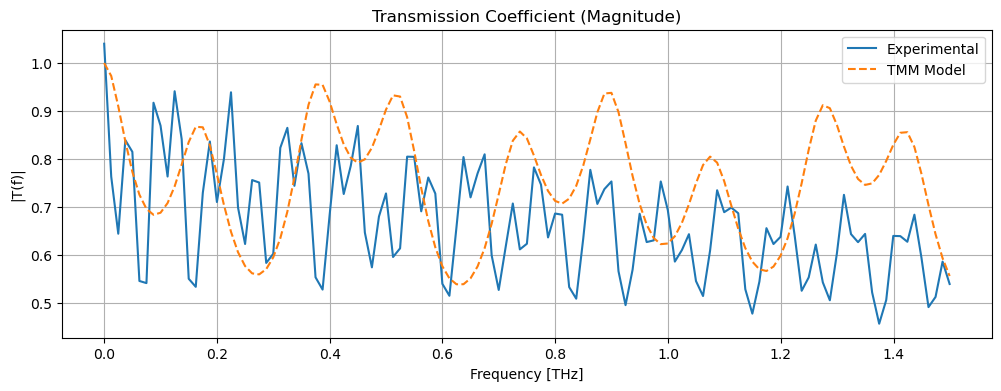

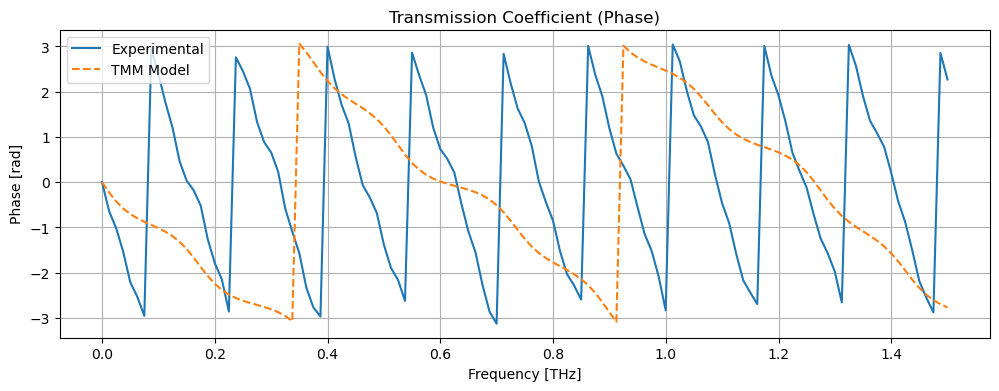

In [47]:
# --- Experimental transmission from data ---
freqs_ref, spec_ref = get_frequency_domain(reference_pulse, deltat)
_, spec_samp = get_frequency_domain(experimental_pulse, deltat)
T_exp = spec_samp / spec_ref  # Experimental transfer function

# --- Model transmission from TMM ---
T_model_full, _ = simulate_parallel(reference_pulse, material_params_exp, deltat)
# Downsample to same frequency resolution as experimental FFT
L = len(reference_pulse)
T_model = T_model_full[:L]  # Match positive + negative frequencies in exp data

# --- Frequency mask for 0–4 THz ---
freqs_thz = freqs_ref[:L//2] * 1e-12
mask = freqs_thz <= 1.5

# --- Plot magnitude ---
plt.figure(figsize=(12,4))
plt.title("Transmission Coefficient (Magnitude)")
plt.plot(freqs_thz[mask], np.abs(T_exp[:L//2][mask].detach().numpy()), label="Experimental")
plt.plot(freqs_thz[mask], np.abs(T_model[:L//2][mask].detach().numpy()), label="TMM Model", linestyle="--")
plt.xlabel("Frequency [THz]")
plt.ylabel("|T(f)|")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot phase ---
plt.figure(figsize=(12,4))
plt.title("Transmission Coefficient (Phase)")
plt.plot(freqs_thz[mask], np.angle(T_exp[:L//2][mask].detach().numpy()), label="Experimental")
plt.plot(freqs_thz[mask], np.angle(T_model[:L//2][mask].detach().numpy()), label="TMM Model", linestyle="--")
plt.xlabel("Frequency [THz]")
plt.ylabel("Phase [rad]")
plt.legend()
plt.grid(True)
plt.show()

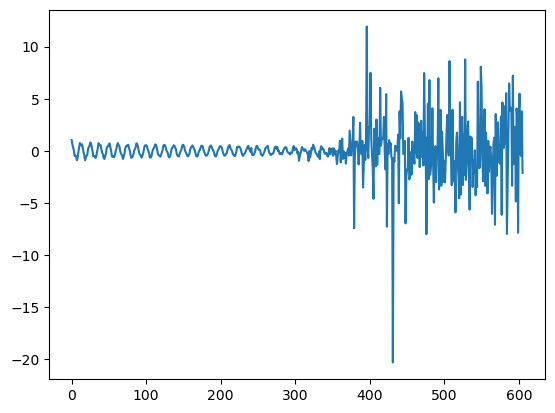

In [48]:
plt.plot(np.real(T_exp.detach().cpu().numpy()[:len(T_exp)//4]))
plt.show()


In [49]:

# Initial guesses, CASE A

n_Qa = 1.9
k_Qa= -0.008
d_Qa =980e-6
n_HRZ_Si= 3.1
k_HRZ_Si = -0.002
d_HRZ_Si = 370e-6

optimize_mask = [
    (True, True, True),  # Qa
    (True, True, True)  # HRZ_Si
]

init_guess = [
   
    ((n_Qa + 1j*k_Qa), d_Qa),  # Qa
    ((n_HRZ_Si + 1j*k_HRZ_Si), d_HRZ_Si),  # HRZ_Si
  
]

optimization_bounds = [0.4,0.001,50e-06]

initial_pulse = simulate_parallel(reference_pulse, init_guess, deltat)[1].detach().cpu().numpy()[:L]

Bayesian_optimizer = BayesianLayeredExtractor(reference_pulse, experimental_pulse, deltat, init_guess, optimization_bounds=optimization_bounds,optimize_mask=optimize_mask)
Bayesian_inits = Bayesian_optimizer.bayesian_optimization(n_calls=60)

Bayesian_pulse = simulate_parallel(reference_pulse, Bayesian_inits, deltat, noise_level=0)[1].detach().cpu().numpy()[:L]

print(Bayesian_inits)
print(material_params_exp)

Starting Bayesian Optimization with masks...
Search Boundaries for Optimized Parameters:
Layer 1 - n ∈ (1.5, 2.3)
Layer 1 - k ∈ (-0.009000000000000001, -0.007)
Layer 1 - D ∈ (0.0009299999999999999, 0.0010299999999999999)
Layer 2 - n ∈ (2.7, 3.5)
Layer 2 - k ∈ (-0.003, -0.001)
Layer 2 - D ∈ (0.00031999999999999997, 0.00042)
[((1.9480275773355544-0.009000000000000001j), 0.001005636726730304), ((3.4071719466322716-0.0019710237293406796j), 0.0004039546636936551)]
[[(1.962-0.0071j), 0.001], [(3.41-0.0054j), 0.0004]]


In [50]:
init_errors = compare_material_stacks(init_guess, material_params_exp)
for e in init_errors:
    print(f"Layer {e['layer']}: "
        f"n_real_abs_err={e['n_real_abs_err']:.6g} ({e['n_real_pct_err']:.2f}%), "
        f"n_imag_abs_err={e['n_imag_abs_err']:.6g} ({e['n_imag_pct_err']:.2f}%), "
        f"d_abs_err={e['d_abs_err']:.6g} ({e['d_pct_err']:.2f}%)")

Layer 1: n_real_abs_err=0.062 (3.16%), n_imag_abs_err=0.0009 (12.68%), d_abs_err=2e-05 (2.00%)
Layer 2: n_real_abs_err=0.31 (9.09%), n_imag_abs_err=0.0034 (62.96%), d_abs_err=3e-05 (7.50%)


In [51]:
errors = compare_material_stacks(Bayesian_inits, material_params_exp)
for e in errors:
    print(f"Layer {e['layer']}: "
        f"n_real_abs_err={e['n_real_abs_err']:.6g} ({e['n_real_pct_err']:.2f}%), "
        f"n_imag_abs_err={e['n_imag_abs_err']:.6g} ({e['n_imag_pct_err']:.2f}%), "
        f"d_abs_err={e['d_abs_err']:.6g} ({e['d_pct_err']:.2f}%)")

Layer 1: n_real_abs_err=0.0139724 (0.71%), n_imag_abs_err=0.0019 (26.76%), d_abs_err=5.63673e-06 (0.56%)
Layer 2: n_real_abs_err=0.00282805 (0.08%), n_imag_abs_err=0.00342898 (63.50%), d_abs_err=3.95466e-06 (0.99%)


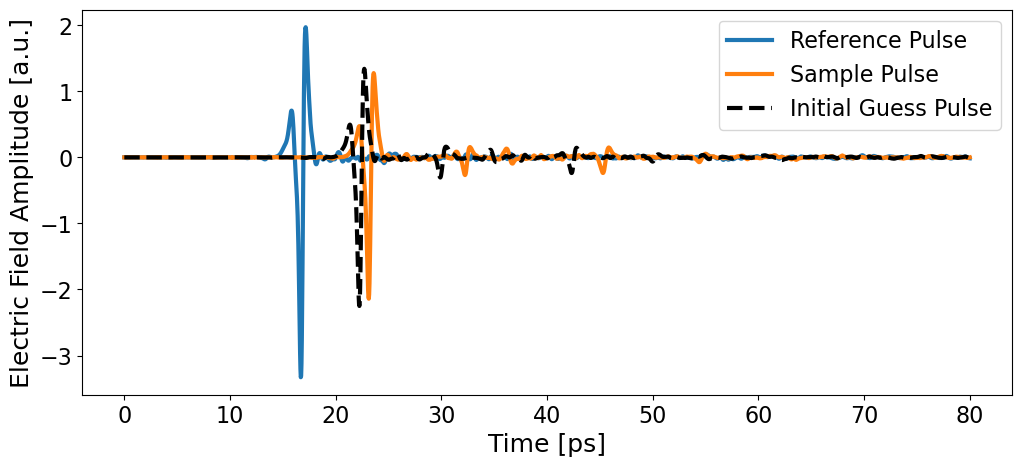

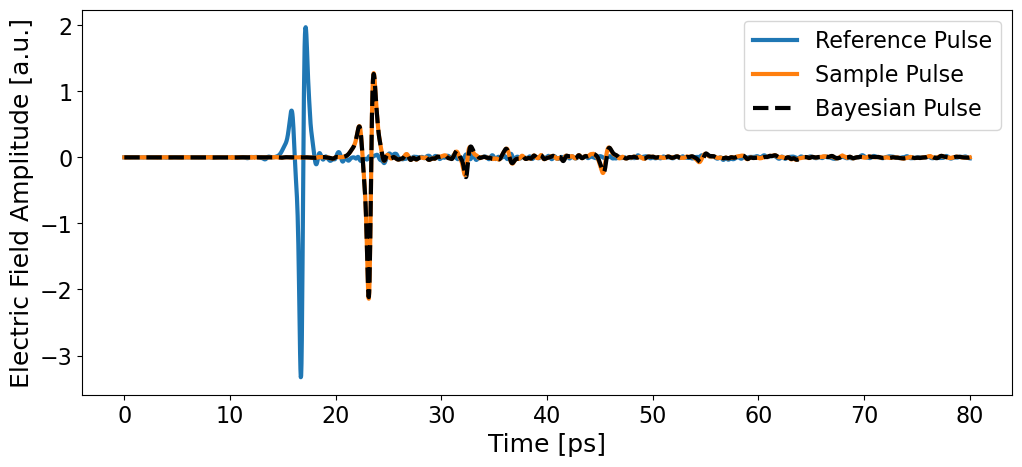

In [52]:
plt.figure(figsize=(12,5))
plt.plot(t_axis*1e12, reference_pulse, label='Reference Pulse', linewidth='3')
plt.plot(t_axis*1e12, experimental_pulse.detach().cpu().numpy(), label='Sample Pulse', linewidth='3')
plt.plot(t_axis*1e12, initial_pulse, label='Initial Guess Pulse', color='k', linestyle='--', linewidth='3')
plt.xlabel('Time [ps]', fontsize=18)
plt.ylabel('Electric Field Amplitude [a.u.]', fontsize=18)
plt.xticks(fontsize=16)  # Increase x-axis tick labels font size
plt.yticks(fontsize=16)  # Increase y-axis tick labels font size
plt.legend(fontsize=16)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(t_axis*1e12, reference_pulse, label='Reference Pulse', linewidth='3')
plt.plot(t_axis*1e12, experimental_pulse.detach().cpu().numpy(), label='Sample Pulse', linewidth='3')
plt.plot(t_axis*1e12, Bayesian_pulse, label='Bayesian Pulse', color='k', linestyle='--', linewidth='3')
plt.xlabel('Time [ps]', fontsize=18)
plt.ylabel('Electric Field Amplitude [a.u.]', fontsize=18)
plt.xticks(fontsize=16)  # Increase x-axis tick labels font size
plt.yticks(fontsize=16)  # Increase y-axis tick labels font size
plt.legend(fontsize=16)
plt.show()

Fine-tuning 6 parameters for 2500 iterations.
Iteration 199, Loss: 1.032108e-03, Layer 0: n=1.9621, k=-0.00714, D=999.98 µm | Layer 1: n=3.4095, k=-0.00529, D=400.07 µm
Iteration 399, Loss: 1.028845e-03, Layer 0: n=1.9621, k=-0.00713, D=1000.00 µm | Layer 1: n=3.4096, k=-0.00529, D=400.05 µm
Iteration 599, Loss: 1.081803e-03, Layer 0: n=1.9620, k=-0.00715, D=999.95 µm | Layer 1: n=3.4097, k=-0.00532, D=400.01 µm
Iteration 799, Loss: 1.037914e-03, Layer 0: n=1.9620, k=-0.00716, D=999.97 µm | Layer 1: n=3.4098, k=-0.00533, D=400.00 µm
Iteration 999, Loss: 1.040993e-03, Layer 0: n=1.9620, k=-0.00713, D=1000.04 µm | Layer 1: n=3.4099, k=-0.00531, D=400.02 µm
Iteration 1199, Loss: 1.042580e-03, Layer 0: n=1.9620, k=-0.00713, D=999.99 µm | Layer 1: n=3.4100, k=-0.00532, D=399.99 µm
Iteration 1399, Loss: 1.034370e-03, Layer 0: n=1.9620, k=-0.00713, D=1000.05 µm | Layer 1: n=3.4101, k=-0.00532, D=400.00 µm
Iteration 1599, Loss: 1.027796e-03, Layer 0: n=1.9619, k=-0.00710, D=1000.01 µm | Layer 

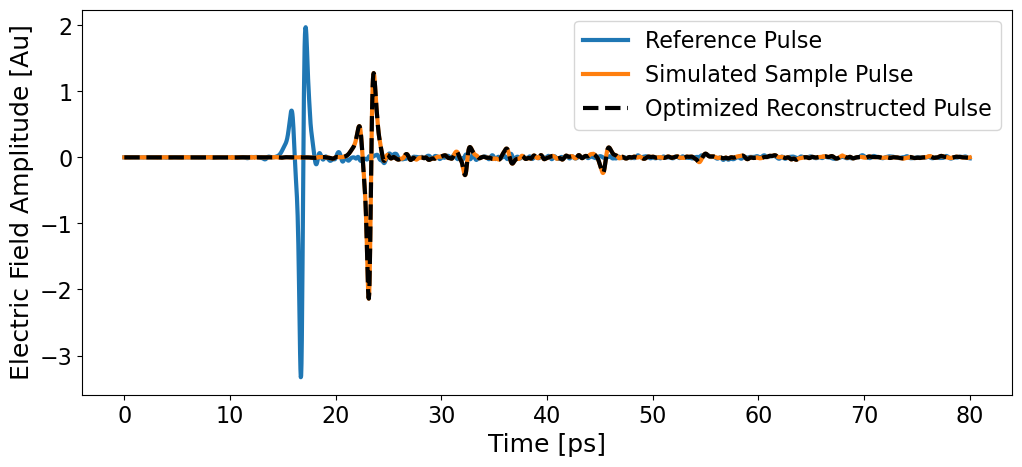

In [53]:
LE = LayeredExtractor(reference_pulse, experimental_pulse, deltat, Bayesian_inits, lr=0.001, optimize_mask=optimize_mask)
optim_params = LE.optimize(num_iterations=2500, updates=200 , alpha=1)



_, optimal_pulse = simulate_parallel(reference_pulse, optim_params, deltat, noise_level=0)
optimal_pulse = optimal_pulse[:L]

print(optim_params)
plt.figure(figsize=(12,5))
plt.plot(t_axis*1e12, reference_pulse, label='Reference Pulse', linewidth='3')
plt.plot(t_axis*1e12, experimental_pulse.detach().cpu().numpy(), label='Simulated Sample Pulse', linewidth='3')
plt.plot(t_axis*1e12, optimal_pulse.detach().cpu().numpy(), label='Optimized Reconstructed Pulse', color='k', linestyle='--', linewidth='3')
plt.xlabel('Time [ps]', fontsize=18)
plt.ylabel('Electric Field Amplitude [Au]', fontsize=18)
plt.xticks(fontsize=16)  # Increase x-axis tick labels font size
plt.yticks(fontsize=16)  # Increase y-axis tick labels font size
plt.legend(fontsize=16)
plt.show()

In [54]:
# To print final paramers in a more readable format
for i, (n_complex, d) in enumerate(optim_params):   
    print(f"Layer {i+1}: n = {n_complex:.4f}, d = {d*1e6:.3f} um")
        

Layer 1: n = 1.9621-0.0071j, d = 999.948 um
Layer 2: n = 3.4094-0.0053j, d = 400.066 um


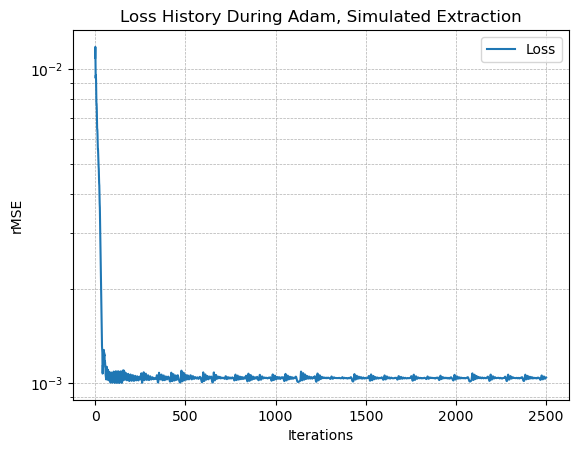

In [55]:
plt.semilogy(LE.loss_history, label='Loss')
plt.xlabel("Iterations")
plt.ylabel("rMSE")
plt.grid(True, which="both", ls="--", linewidth=0.5)
#plt.xlim(100, 2000)
plt.title("Loss History During Adam, Simulated Extraction")
plt.legend()
plt.show()

In [56]:
print("Minimum loss: ", min(LE.loss_history))

Minimum loss:  0.0010013782884925604


In [ ]:
# CASE A
''' Layer 1: n = 1.9539-0.0063j, d = 1004.186 um 
    Layer 2: n = 3.4459-0.0070j, d = 395.842 um '''


# CASE B
''' Layer 1: n = 1.9621-0.0071j, d = 999.948 um
    Layer 2: n = 3.4094-0.0053j, d = 400.066 um  '''





' Layer 1: n = 1.9539-0.0063j, d = 1004.186 um \n    Layer 2: n = 3.4459-0.0070j, d = 395.842 um '

In [61]:
# COMPARISON BETWEEN THE MINIMUM LOSSES FOR CASE A AND CASE B

loss_diff = abs((0.0010339-0.0010013782884925604)/0.0010339) *100 

print(f"The percentage difference in minimum loss between Case A and Case B [simulated] is: {loss_diff:.3f}%")

The percentage difference in minimum loss between Case A and Case B [simulated] is: 3.146%


In [62]:
# SIMULATED MINIMUM LOSS VALUES
min_loss_A = 0.0010339
min_loss_B = 0.0010013